# 01 · Exploratory Data Analysis
Understand the DGA dataset before modelling: coverage, gas distributions, conventional-fault mix, and the field-event notes used as weak validation labels.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from dga.config import load_config, set_seed
cfg = load_config(); set_seed(cfg.seed)

In [2]:
from dga import data as dga_data
df = dga_data.load_clean()
print(df.shape, '|', df['CODETX'].nunique(), 'transformers', '|', df['MFG'].nunique(), 'manufacturers')
df.head()

(4563, 26) | 628 transformers | 42 manufacturers


,LOC,NAME,CODETX,MFG,SER,KV,MVA,YEAR_Energized,Sample Day,Tested day,...,C2H2,C2H4,C2H6,C3H6,C3H8,TCG,TEMP,WATER,NB,has_note
sample_id,,,,,,,,,,,,,,,,,,,,,
0,KTL,KT1A,KTLKT1A,VOLTA WERKE,60539-003,115/22,25,1993.0,2023-12-11,2023-12-14,...,98.0,47.0,23.0,22.0,12.0,597.0,34,10,หลัง TRIP เมื่อวันที่ 10/12/52 (15.30),True
1,PHG,KT1A,PHGKT1A,JEUMONT,92199,230/115/22,200,1995.0,2019-09-14,2019-09-14,...,954.0,386.0,85.0,95.0,19.0,2824.0,28,7,Bushing LowSide Phase.C ระเบิด,True
2,BLG,KT1A,BLGKT1A,ELIN,535959,107/34.85,8,1977.0,2019-09-06,2019-10-18,...,95.0,47.0,14.0,21.0,0.0,616.0,58,26,<NA>,False
3,BLG,KT1A,BLGKT1A,ELIN,535959,107/34.85,8,1977.0,2023-06-26,2023-07-17,...,9.0,8.0,3.0,2.0,7.0,73.0,38,17,ค่า p.f สูง,True
4,SR2,KT1A,SR2KT1A,MITSUBISHI,573077,115/22,40,1998.0,2020-02-10,2020-02-22,...,893.0,276.0,557.0,73.0,335.0,2827.0,-,23,Research เก็บน้ำมันก่อนที่จะทำการตัดกระดาษ,True


## Per-gas summary
Note the extreme skew (median C2H2/C2H4 near 0) and the absurd O2 outlier — both motivate log1p + outlier clipping.

In [3]:
dga_data.summary(df)

,n,missing,min,median,max
gas,,,,,
O2,4563,0,0.0,7968.0,719534824.0
N2,4563,0,0.0,45891.0,670900.0
CO2,4563,0,0.0,2281.0,23574.0
CO,4563,0,0.0,193.0,2437.0
H2,4563,0,0.0,16.0,2537.0
CH4,4563,0,0.0,18.0,2469.0
C2H2,4563,0,0.0,0.0,954.0
C2H4,4563,0,0.0,2.0,3394.0
C2H6,4563,0,0.0,14.0,1085.0


## Gas distributions (log scale)

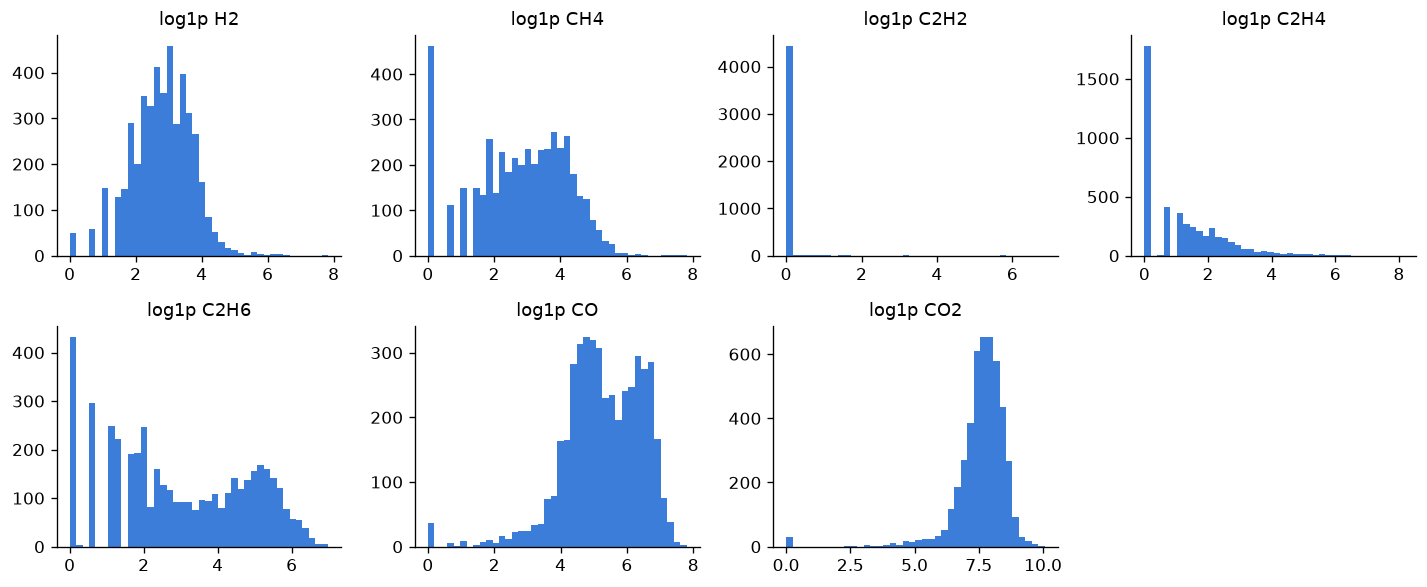

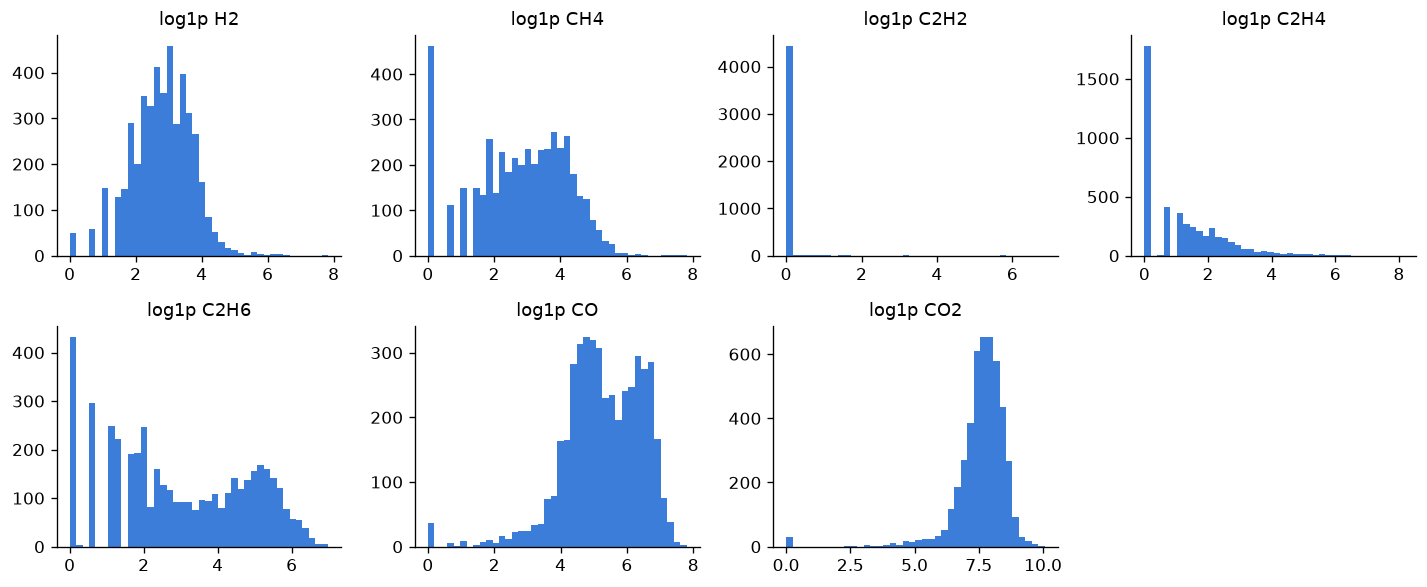

In [4]:
from dga import viz
viz.set_paper_style()
fig = viz.plot_gas_distributions(df, cfg.data.feature_gases, log=True)
fig

## Field-event notes (weak labels)
391 rows carry a free-text note describing a real event (Buchholz trip, bushing explosion...). These validate anomaly detection.

In [5]:
notes = df[df['has_note']]
print(len(notes), 'rows with a note')
notes[['LOC','MFG','Sample Day','H2','C2H2','C2H4','TCG','NB']].head(10)

391 rows with a note


,LOC,MFG,Sample Day,H2,C2H2,C2H4,TCG,NB
sample_id,,,,,,,,
0,KTL,VOLTA WERKE,2023-12-11,133.0,98.0,47.0,597.0,หลัง TRIP เมื่อวันที่ 10/12/52 (15.30)
1,PHG,JEUMONT,2019-09-14,750.0,954.0,386.0,2824.0,Bushing LowSide Phase.C ระเบิด
3,BLG,ELIN,2023-06-26,7.0,9.0,8.0,73.0,ค่า p.f สูง
4,SR2,MITSUBISHI,2020-02-10,302.0,893.0,276.0,2827.0,Research เก็บน้ำมันก่อนที่จะทำการตัดกระดาษ
5,BK,ABB,2021-08-04,148.0,82.0,165.0,1712.0,Bouchholz relay Trip(พบสาย Lead Bushing Neutra...
6,BK,ABB,2021-08-03,273.0,80.0,114.0,2140.0,Buchholz and Sudden pressure RelayTrip
10,PDG,TOSHIBA,2021-07-09,2537.0,612.0,851.0,5816.0,เนื่องจาก BUSHING KT1AB ระเบิด
14,LE,RADE KONCAR,2019-04-04,704.0,586.0,219.0,1749.0,"Tx.trip Buchholz relay,transformer diff.relayม..."
20,KB2,JEUMONT,2019-10-05,250.0,47.0,2734.0,7020.0,oil temperature alarm


## Correlation of diagnostic gases (log space)

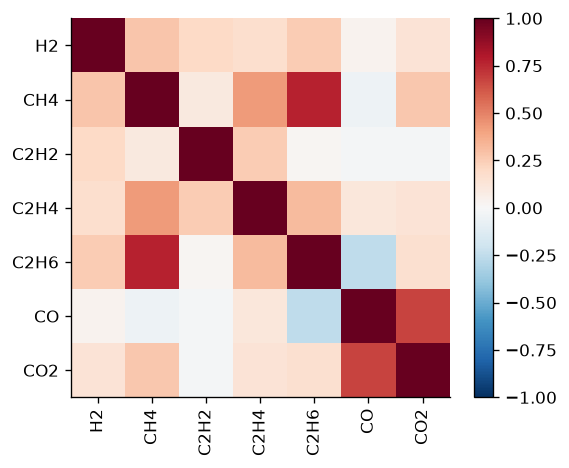

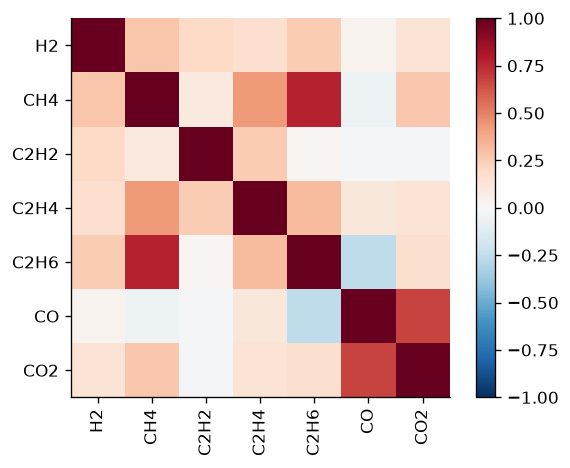

In [6]:
import numpy as np
g = np.log1p(df[cfg.data.feature_gases].fillna(0))
fig, ax = plt.subplots(figsize=(5,4)); im = ax.imshow(g.corr(), vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(g.columns))); ax.set_xticklabels(g.columns, rotation=90)
ax.set_yticks(range(len(g.columns))); ax.set_yticklabels(g.columns); fig.colorbar(im); fig

## Missingness, sparsity & skew
After cleaning, gas values have ~0 % NaN — the *sparsity* shows up as **zeros**, not missing data (e.g. no acetylene = no arcing). Per-gas zero-fraction tells us which gases are informative; the raw vs `log1p` skew justifies the log transform (C2H2/C2H4 stay heavy even in log).

In [7]:
gases = cfg.data.all_gases
rows = []
for g in gases:
    s = df[g]
    rows.append({
        'gas': g,
        'pct_miss': round(s.isna().mean() * 100, 1),
        'pct_zero': round((s == 0).mean() * 100, 1),
        'max': s.max(),
        'skew_raw': round(s.dropna().skew(), 1),
        'skew_log1p': round(np.log1p(s.dropna()).skew(), 2),
    })
sparsity = pd.DataFrame(rows).set_index('gas')
sparsity

,pct_miss,pct_zero,max,skew_raw,skew_log1p
gas,,,,,
O2,0.0,0.0,719534824.0,67.5,-0.02
N2,0.0,0.0,670900.0,8.5,-5.86
CO2,0.0,0.7,23574.0,2.3,-3.32
CO,0.0,0.8,2437.0,1.4,-1.02
H2,0.0,1.1,2537.0,30.2,-0.18
CH4,0.0,10.1,2469.0,15.2,-0.36
C2H2,0.0,97.4,954.0,27.1,10.18
C2H4,0.0,39.1,3394.0,28.4,1.10
C2H6,0.0,9.5,1085.0,2.6,0.07


## The O2 data-entry outlier
One O2 reading is ≈ 7.2×10⁸ ppm — physically impossible (air is ~2.1×10⁵ ppm O2). It motivates the 99.9-quantile clip in preprocessing. O2 is excluded from model features anyway, but the clip guards any feature gas with a stray entry.

In [8]:
print('O2 max         :', df['O2'].max())
print('O2 99.9% quant :', round(df['O2'].quantile(0.999), 1))
df.nlargest(3, 'O2')[['CODETX', 'MFG', 'Sample Day', 'O2', 'N2', 'TCG']]

O2 max         : 719534824
O2 99.9% quant : 67994.9


,CODETX,MFG,Sample Day,O2,N2,TCG
sample_id,,,,,,
448,BNKT8A,FUJI,2020-06-03,719534824,34824,451.0
2699,PNKT1A,FUJI,2020-11-30,245592,172990,308.0
4389,WNKT1AA,GEC ALSTHOM,2020-10-03,197077,58509,537.0


## Conventional fault mix (Duval) — weak external labels
`conventional.diagnose` assigns each sample a Duval Triangle 1 class. The mix is **highly imbalanced** (PD+T1 ≈ 65 %, arcing D1/D2/DT ≈ 1.5 %) with ~8 % *not-determined*. Keep this in mind when reading ARI/NMI later: a severity-driven 2-cluster split can score a high silhouette yet near-zero ARI against these 7 classes.

not-determined: 7.7%


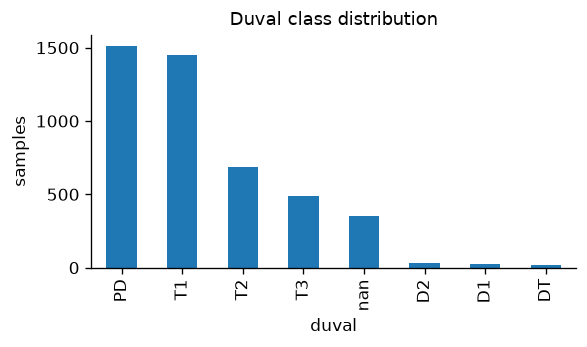

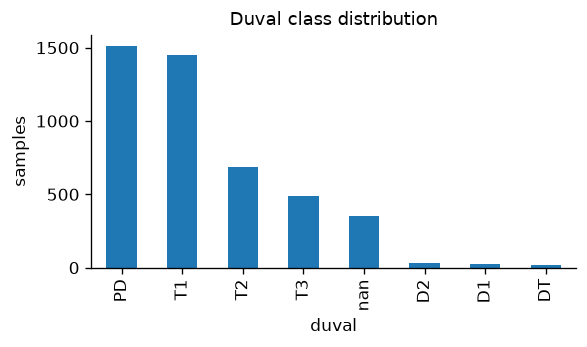

In [9]:
from dga import conventional
diag = conventional.diagnose(df)
counts = diag['duval'].value_counts(dropna=False)
print('not-determined: %.1f%%' % (diag['duval'].isna().mean() * 100))
fig, ax = plt.subplots(figsize=(5, 3))
counts.plot.bar(ax=ax); ax.set_ylabel('samples'); ax.set_title('Duval class distribution')
fig

## Locked dataset facts & preprocessing decisions (Week 1)

**Dataset:** 4,563 main-tank samples · 628 transformers · 42 manufacturers · 2019–2024.

**Model features (7):** `H2, CH4, C2H2, C2H4, C2H6, CO, CO2`. Atmospheric `O2`/`N2` and the derived `TCG` are excluded (TCG is a sum of the others → leakage).

**Preprocessing:** clip at the 99.9-quantile (removes O2-style data-entry errors) → `log1p` (heavy right-skew, even in log for C2H2/C2H4) → standard scale.

**Labels:** 391 rows (8.6 %) carry a field-event note → weak positives for anomaly-detection validation. The Duval class is the external label for ARI/NMI, treated as *indicative only* (heavily imbalanced; ~8 % not-determined).

**Caveat:** `KV` is free-text multi-winding (e.g. `"115/22"`, `"69/22/11"`), not a clean numeric — do not model it as-is.

> These mirror `config/default.yaml`; run experiments by editing the config, not the code.